#### Use a Titanic Dataset and perform the data cleaning process by handling the outliers and check whther the passenger has survived or not


###### Step 1: Import all the necessary libraries

In [1525]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns
import  joblib


from    sklearn.model_selection     import      train_test_split
from    sklearn.preprocessing       import      StandardScaler
from    sklearn.linear_model        import      LinearRegression
from    sklearn.metrics             import      accuracy_score, confusion_matrix, classification_report

##### Step 2: Load the Dataset

In [1526]:
df   =   pd.read_csv("Titanic_Dataset.csv")

In [1527]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


#### Step 3: Perform the Data Exploration

In [1528]:
#### get the total records used in the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 891


In [1529]:
#### shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (891, 12)


In [1530]:
#### get all the columns from the dataset

df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [1531]:
#### get the information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [1532]:
#### get the descriptive summary statistics about the data in the dataset

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### Step 4: Perform the Data Cleaning

In [1533]:
#### get the null records from the dataset

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

####  (a.)  Handling Missing Values

In [1534]:
#### Remove all the NULL records from the dataset


##### Replace all the NULL Values in Age column with the median value

df['Age'].fillna(df['Age'].mean(), inplace=True)

In [1535]:
##### Replace all the NULL Values in Cabin column with the mode value

df['Cabin'].fillna(df['Cabin'].mode()[0], inplace=True)

In [1536]:
##### Replace all the NULL Values in Embarked column with the mode value

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

In [1537]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,B96 B98,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,B96 B98,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,B96 B98,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


In [1538]:
#### Again get the null records from the dataset

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL Values in the dataset.

In [1539]:
#### Check for any duplicate records in the dataset

df[df.duplicated()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

#### (b.)  Handle Outliers

<Axes: ylabel='Age'>

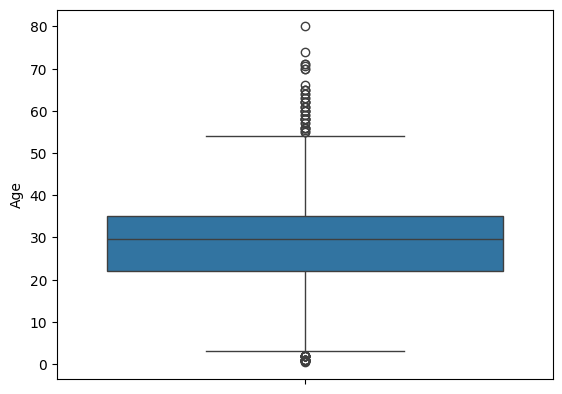

In [1540]:
import seaborn as sns

sns.boxplot(df['Age'])

#### OBSERVATIONS:

1.  There are some outliers in the dataset.

In [1541]:
### Find out first quartile

Q1 = df['Age'].quantile(0.25)

print("First Quantile:" , Q1)

First Quantile: 22.0


In [1542]:
### Find out third quartile

Q3 = df['Age'].quantile(0.75)

print("Third Quantile:" , Q3)

Third Quantile: 35.0


In [1543]:
#### Find out the Inter quantile range

IQR = Q3 - Q1

print("Interquantile Range is:", IQR)

Interquantile Range is: 13.0


In [1544]:
#### Compute the lower bound and upper bound

lower_bound = Q1 - (1.5 * IQR)

upper_bound = Q3 + (1.5 * IQR)

In [1545]:
print("Lower Bound is:", lower_bound)


print("Upper Bound is:", upper_bound)

Lower Bound is: 2.5
Upper Bound is: 54.5


In [1546]:
#### Remove the Outliers that lie beyond the range


df = df[(df['Age'] > lower_bound) & (df['Age'] < upper_bound)]

In [1547]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,B96 B98,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,B96 B98,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,B96 B98,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


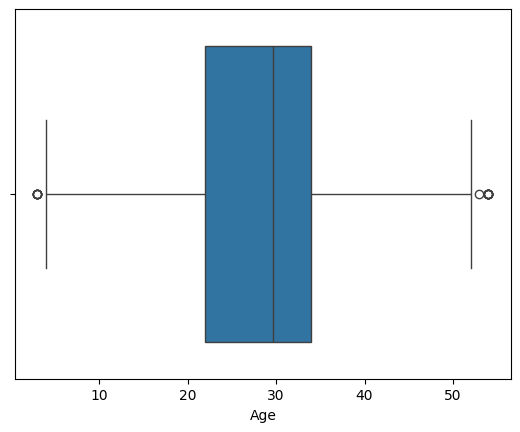

In [1548]:
sns.boxplot(x=df['Age'])
plt.show()

#### OBSERVATIONS:

1.  Now there are no outliers left in the dataset.

In [1549]:
#### To check for the duplicate records in the dataset

df[df.duplicated()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


#### OBSERVATIONS:

1.  There are no duplicate records left in the dataset.

In [1550]:
#### Drop the unnecessary columns from the dataset

df.drop(columns = ['Name', 'Ticket', 'PassengerId'],axis=1, inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_14332\2343075340.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns = ['Name', 'Ticket', 'PassengerId'],axis=1, inplace=True)


In [1551]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.000000,1,0,7.2500,B96 B98,S
1,1,1,female,38.000000,1,0,71.2833,C85,C
2,1,3,female,26.000000,0,0,7.9250,B96 B98,S
3,1,1,female,35.000000,1,0,53.1000,C123,S
4,0,3,male,35.000000,0,0,8.0500,B96 B98,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,B96 B98,S
887,1,1,female,19.000000,0,0,30.0000,B42,S
888,0,3,female,29.699118,1,2,23.4500,B96 B98,S
889,1,1,male,26.000000,0,0,30.0000,C148,C


#### Step 5: Perform Label Encoding on the Categorical columns

In [1552]:
from sklearn.preprocessing import LabelEncoder


label = LabelEncoder()

#### use the object of label encoding to transform the categorical columns into the numerical columns

df['Sex'] = label.fit_transform(df['Sex'])

C:\Users\DELL\AppData\Local\Temp\ipykernel_14332\3778565811.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = label.fit_transform(df['Sex'])


In [1553]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,1,22.000000,1,0,7.2500,B96 B98,S
1,1,1,0,38.000000,1,0,71.2833,C85,C
2,1,3,0,26.000000,0,0,7.9250,B96 B98,S
3,1,1,0,35.000000,1,0,53.1000,C123,S
4,0,3,1,35.000000,0,0,8.0500,B96 B98,S
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,B96 B98,S
887,1,1,0,19.000000,0,0,30.0000,B42,S
888,0,3,0,29.699118,1,2,23.4500,B96 B98,S
889,1,1,1,26.000000,0,0,30.0000,C148,C


In [1554]:
#### Again remove all the unnecessary columns from the dataset

df.drop(columns=['Pclass','SibSp','Parch','Cabin','Embarked'],axis=1,inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_14332\929157167.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['Pclass','SibSp','Parch','Cabin','Embarked'],axis=1,inplace=True)


In [1555]:
df

,Survived,Sex,Age,Fare
0,0,1,22.000000,7.2500
1,1,0,38.000000,71.2833
2,1,0,26.000000,7.9250
3,1,0,35.000000,53.1000
4,0,1,35.000000,8.0500
...,...,...,...,...
886,0,1,27.000000,13.0000
887,1,0,19.000000,30.0000
888,0,0,29.699118,23.4500
889,1,1,26.000000,30.0000


In [1556]:
df['Survived'].value_counts()

Survived
0    511
1    314
Name: count, dtype: int64

In [1557]:
#### perform the upsampling on the minority class

df_majority = df[df['Survived'] == 0]

df_minority = df[df['Survived'] == 1]

In [1558]:
df_majority

,Survived,Sex,Age,Fare
0,0,1,22.000000,7.2500
4,0,1,35.000000,8.0500
5,0,1,29.699118,8.4583
6,0,1,54.000000,51.8625
12,0,1,20.000000,8.0500
...,...,...,...,...
884,0,1,25.000000,7.0500
885,0,0,39.000000,29.1250
886,0,1,27.000000,13.0000
888,0,0,29.699118,23.4500


In [1559]:
df_minority

,Survived,Sex,Age,Fare
1,1,0,38.0,71.2833
2,1,0,26.0,7.9250
3,1,0,35.0,53.1000
8,1,0,27.0,11.1333
9,1,0,14.0,30.0708
...,...,...,...,...
874,1,0,28.0,24.0000
875,1,0,15.0,7.2250
880,1,0,25.0,26.0000
887,1,0,19.0,30.0000


In [1560]:
from sklearn.utils import resample

df_minority_resample = resample(
    df_minority                                      ,
    replace              =          True             ,
    n_samples            =         len(df_majority)  ,
    random_state         =            42
)

In [1561]:
df_minority_resample

,Survived,Sex,Age,Fare
303,1,0,29.699118,12.3500
750,1,0,4.000000,23.0000
310,1,0,24.000000,83.1583
220,1,1,16.000000,8.0500
523,1,0,44.000000,57.9792
...,...,...,...,...
106,1,0,21.000000,7.6500
315,1,0,26.000000,7.8542
507,1,1,29.699118,26.5500
123,1,0,32.500000,13.0000


In [1562]:
df = pd.concat([df_majority, df_minority_resample])

In [1563]:
df

,Survived,Sex,Age,Fare
0,0,1,22.000000,7.2500
4,0,1,35.000000,8.0500
5,0,1,29.699118,8.4583
6,0,1,54.000000,51.8625
12,0,1,20.000000,8.0500
...,...,...,...,...
106,1,0,21.000000,7.6500
315,1,0,26.000000,7.8542
507,1,1,29.699118,26.5500
123,1,0,32.500000,13.0000


In [1564]:
df['Survived'].value_counts()

Survived
0    511
1    511
Name: count, dtype: int64

#### OBSERVATIONS:

1.  The dataset is balanced as there are equal number of 1's and 0's in the dataset.

#### Step 6: Divide the dataset into independent and dependent features

In [1565]:
#### Independent features

X = df.drop(columns=['Survived'], axis=1)

#### dependent features

Y = df['Survived']

In [1566]:
print(X)

     Sex        Age     Fare
0      1  22.000000   7.2500
4      1  35.000000   8.0500
5      1  29.699118   8.4583
6      1  54.000000  51.8625
12     1  20.000000   8.0500
..   ...        ...      ...
106    0  21.000000   7.6500
315    0  26.000000   7.8542
507    1  29.699118  26.5500
123    0  32.500000  13.0000
516    0  34.000000  10.5000

[1022 rows x 3 columns]


In [1567]:
print(Y)

0      0
4      0
5      0
6      0
12     0
      ..
106    1
315    1
507    1
123    1
516    1
Name: Survived, Length: 1022, dtype: int64


#### Step 7: Divide the independent and dependent features into the training and testing data

In [1568]:
from sklearn.model_selection import train_test_split

X_train, X_test , Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [1569]:
X_train

,Sex,Age,Fare
231,1,29.000000,7.7750
10,0,4.000000,16.7000
697,0,29.699118,7.7333
323,0,22.000000,29.0000
151,0,22.000000,66.6000
...,...,...,...
177,0,50.000000,28.7125
480,1,9.000000,46.9000
457,0,29.699118,51.8625
769,1,32.000000,8.3625


In [1570]:
X_test

,Sex,Age,Fare
596,0,29.699118,33.0000
837,1,29.699118,8.0500
604,1,35.000000,26.5500
63,1,4.000000,27.9000
300,0,29.699118,7.7500
...,...,...,...
793,1,29.699118,30.6958
701,1,35.000000,26.2875
608,0,22.000000,41.5792
569,1,32.000000,7.8542


In [1571]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (817, 3)
Shape of the input testing  data is: (205, 3)


In [1572]:
Y_train

231    0
10     1
697    1
323    1
151    1
      ..
177    0
480    0
457    1
769    0
171    0
Name: Survived, Length: 817, dtype: int64

In [1573]:
Y_test

596    1
837    0
604    1
63     0
300    1
      ..
793    0
701    1
608    1
569    1
460    1
Name: Survived, Length: 205, dtype: int64

In [1574]:
print("Shape of the output  training data is:", Y_train.shape)
print("Shape of the output  testing  data is:", Y_test.shape)

Shape of the output  training data is: (817,)
Shape of the output  testing  data is: (205,)


#### Step 8: Perform the Feature Scaling on the inputs

In [1575]:
from sklearn.preprocessing import StandardScaler

#### create an object for StandardScaler

sc = StandardScaler()

#### using the object of Standard Scaler, transform the model

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled = sc.transform(X_test)

In [1576]:
X_train_scaled

array([[ 0.90308115,  0.01091825, -0.52343499],
       [-1.10732021, -2.36787132, -0.33515305],
       [-1.10732021,  0.0774404 , -0.5243147 ],
       ...,
       [-1.10732021,  0.0774404 ,  0.40663563],
       [ 0.90308115,  0.296373  , -0.51104108],
       [ 0.90308115, -2.36787132, -0.07303504]], shape=(817, 3))

In [1577]:
X_test_scaled

array([[-1.10732021e+00,  7.74403991e-02,  8.71201957e-03],
       [ 9.03081146e-01,  7.74403991e-02, -5.17633590e-01],
       [ 9.03081146e-01,  5.81827745e-01, -1.27357286e-01],
       [ 9.03081146e-01, -2.36787132e+00, -9.88776641e-02],
       [-1.10732021e+00,  7.74403991e-02, -5.23962395e-01],
       [-1.10732021e+00, -2.74536500e-01, -5.20270592e-01],
       [-1.10732021e+00,  7.74403991e-02,  2.40354868e+00],
       [ 9.03081146e-01,  2.01221414e-01,  5.15016413e-01],
       [-1.10732021e+00,  1.72364674e+00, -3.81564284e-01],
       [-1.10732021e+00,  5.81827745e-01,  1.01206487e+01],
       [-1.10732021e+00,  1.34304041e+00,  3.77092284e+00],
       [ 9.03081146e-01,  3.43948788e-01, -5.30824317e-02],
       [-1.10732021e+00,  1.91394990e+00, -1.40453693e-01],
       [ 9.03081146e-01, -8.42333343e-02,  5.04379802e-01],
       [-1.10732021e+00, -1.41635549e+00, -5.30824317e-02],
       [-1.10732021e+00,  1.09182485e-02, -4.65948349e-01],
       [-1.10732021e+00,  1.05758566e+00

#### OBSERVATIONS:

1.  The input features are in the same scale range after applying the feature scaling technique.

#### Step 9: Train the Logistic Regression Model

In [1578]:
from  sklearn.linear_model  import LogisticRegression


#### create an object for Logistic Regression

log = LogisticRegression(max_iter=1000)


#### using the object, train the model

log.fit(X_train_scaled, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Step 10: Predict the Model

In [1579]:
Y_pred = log.predict(X_test_scaled)

In [1580]:
Y_pred

array([1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0])

#### Step 11: Evaluate the Classification Metrics

In [1581]:
from  sklearn.metrics  import  accuracy_score, confusion_matrix, classification_report

In [1582]:
ac = accuracy_score(Y_test, Y_pred)*100.0

print("Accuracy score of the model is:", ac)

Accuracy score of the model is: 72.1951219512195


#### OBSERVATIONS:

1.  The accuracy score of the model is 72.1 which is fine. So the model is good.

In [1583]:
cm = confusion_matrix(Y_test, Y_pred)

print("Confusion Matrix of the model is:", cm)

Confusion Matrix of the model is: [[81 18]
 [39 67]]


In [1584]:
cr = classification_report(Y_test, Y_pred)

print("Classification Report of the model is:", cr)

Classification Report of the model is:               precision    recall  f1-score   support

           0       0.68      0.82      0.74        99
           1       0.79      0.63      0.70       106

    accuracy                           0.72       205
   macro avg       0.73      0.73      0.72       205
weighted avg       0.73      0.72      0.72       205

